In [ ]:
from dq_network import QNetwork, ReplayBuffer
from mdp import WarehouseMDP
import math

: 

In [1]:
# Setup for Google Colab
# Imports
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from collections import deque
from torch.optim.lr_scheduler import MultiStepLR
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/rl-project-warhouse-nav/')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Mounted at /content/drive
Using device: cuda


In [3]:
!cp '/content/drive/MyDrive/rl-project-warhouse-nav/dq_network.py'      /content/dq_network.py
!cp '/content/drive/MyDrive/rl-project-warhouse-nav/mdp.py'      /content/mdp.py

# Imports
from mdp import WarehouseMDP
from dq_network import QNetwork, ReplayBuffer

In [4]:

def encode_mdp(mdp):
  """
  Helper function to encode_state for channels that remain the same:
  channel 0: obstacle: grid with 1 if there is a wall at this position
  channels 1..N: 1 at start position for package i
  channels N + 1 ...2N : storage i for package i 0.5 = empty
  placeholders: 
  channel 2N + 1: position of robot 
  channels 2N + 2...3N + 1 carrying package i init with zeros 
  """
  rows, cols = mdp.grid.shape
  n = mdp.n_packages
  # total channels: 1 + n_packages + n_storages = 2*n_packages + 1
  base = np.zeros((1 + 2*n, rows, cols), dtype=np.float32)
  # channel 0 for obstacles: obstacles remain the same, grid == 1 if obstacle at position (row,col)
  base[0] = (mdp.grid == 1).astype(np.float32)

  # channel for each package:
  for p in range(n):
    row, col = mdp.packages[p]
    base[1 + p, row, col] = 1.0 # 1 at start position of package 

  # channels for storages:
  for s in range(n):
    row, col = mdp.storages[s]
    base[1 + n + s, row, col] = 0.5 # all storages are empty at the beginning

  # place holder for dynamic channels
  dyn = np.zeros((1 + n, rows, cols), dtype=np.float32)

  return np.concatenate([base,dyn] ,axis = 0) # (2 + 3*n_packages, rows ,cols)


def encode_state(state, mdp, base_grid):
    """
    encoding given state s = (robot_pos, carrying, delivered)
    encode as matrix. different channels needed due to positions that can overlapp. 
    concate all channels and flatten for input to network.
    Channels for the position of the agent, position of obstacles, position of packages and position of storages.
    Given N packages:
    channel 0: obstacle: grid with 1 if there is a wall at this position, does not change 
    channels 1..N:  start position for package i. if package i is picked up, change to 0 
    channels N + 1 ...2N : storage i for package i 0.5 = empty. change to 1 if succesfully delivered
    channel 2N + 1: 1 at current position of robot 
    channels 2N + 2...3N + 1 carrying package i. change whole grid to 1 if agent is carrying package i 
    Packages and storage may share the same cell
    Agent may be on the same position than a package or a storage
    """
    # get grid size from given mdp
    rows, cols = mdp.grid.shape
    # get num packages
    n = mdp.n_packages
    pos, carrying, delivered = state
    # copy base_grid to add dynamic channels
    enc = base_grid.copy()

    # update package channsel 1 to N:
    for p in range(n):
      if delivered[p] or carrying == p:
        row, col = mdp.packages[p]
        enc[1 + p, row, col] = 0.0 # package is not on the ground anymore
    # update storage channels: 1 if package i is delivered
    for p in range(n):
      if delivered[p]:
        row, col = mdp.storages[p]
        enc[1 + n + p, row,col] = 1.0

    # add channel for position of robot
    enc[1 + 2*n, pos[0], pos[1]] = 1

    # channel for package that is carried gird with 1:
    if carrying is not None:
      enc[2 + 2*n + carrying, :, : ] = 1.0

    return enc.flatten()

In [5]:
mdp = WarehouseMDP(
    grid=[
        [0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
    ],
    start_pos=(0, 0),
    packages={
        0: (2, 2),
        1: (6, 6)
    },
    storages={
        0: (0, 6),
        1: (6, 0)
    },
)
# encode the mdp 
base_grid = encode_mdp(mdp=mdp)

In [6]:
# define online network and target network
# input dim is defined as every possible configuration the robot can be in
# state s = (robot_pos, carrying, delivered)
# input_dim = base_grid.size
input_dim = base_grid.size
policy_network = QNetwork(input_dim = input_dim, output_dim = mdp.n_actions, hidden_dim = 256).to(device)
target_network = QNetwork(input_dim = input_dim, output_dim = mdp.n_actions, hidden_dim = 256).to(device)
target_network.load_state_dict(policy_network.state_dict()) 
policy_optimizer = torch.optim.Adam(params=policy_network.parameters(), lr=3e-4)

In [7]:
def parameter_update(source_model, target_model, tau):
    for target_param, source_param in zip(target_model.parameters(), source_model.parameters()):
        target_param.data.copy_(tau * source_param.data + (1.0 - tau)*target_param.data)

In [8]:
import math

In [9]:
# setup according to PyTorch tutorial and Lab 8 
BATCH_SIZE = 128
GAMMA = 0.95
# probability of choosing random action starts with EPS_START
#  and decays exponentially towards EPS_END.
EPS_START = 0.9
EPS_END = 0.01
# Controls the rate of decay
EPS_DECAY = 200000
TAU = 0.005
LR = 3e-4
SOFT_UPDATE = 0.001


NUM_TRAJECTORIES = 10000
MAX_EPISODE_LENGTH = 500

# warmup steps to collect the data first
WARMUP = 10000

# placeholders for rewards for each episode
cumulative_rewards = []
policy_losses = []
# declaring the replay buffer
transition_buffer = ReplayBuffer(20000)
steps_done = 0

policy_scheduler = torch.optim.lr_scheduler.MultiStepLR(
    policy_optimizer,
    milestones=[6000, 8000],
    gamma=0.5
)

## Training Loop

In [12]:

# TODO: how to extract policy
#initialize a policy for each episode
policies= {}
action_counts = [0] * mdp.n_actions
# iterating through trajectories
delivered_per_episode = []
for tau in tqdm(range(NUM_TRAJECTORIES)):
    # resetting the environment
    # i.e robot_pos = start_pos, carrying = None, delivered = false for each package in n_packages
    state = mdp.reset()
    # get valid actions for current state
    mask = mdp.action_masks(state)
    # encode state
    state_enc = encode_state(state, mdp, base_grid)
    # setting done to False for while loop
    done = False
    t = 0
    pickup_count  = 0
    deliver_count = 0
    episode_reward = 0.0
    while done == False and t < MAX_EPISODE_LENGTH:
        eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-steps_done/EPS_DECAY)
        steps_done += 1
        # retrieving Q(s, a) for all possible a
        action_q_values = policy_network(torch.tensor(state_enc).to(device))
        # masking actions and only slect valid actions, set others to - inf
        mask = mdp.action_masks(state)

        if np.random.random() < eps_threshold:
            # Exploration only choose a valid action
            valid_actions = np.where(mask == 1)[0]
            action = int(np.random.choice(valid_actions))
        else:
            # Exploitation: invalide actions to - inf then choose arg max
            q_vals = action_q_values.detach().cpu().numpy().flatten()
            q_vals[mask == 0] = -np.inf
            action = int(np.argmax(q_vals))

        action_counts[int(action)] += 1
        # keeping track of previous state
        prev_state_enc = state_enc
        # environment step
        state, reward, done = mdp.step(state, int(action))
        # next_mask
        next_mask = mdp.action_masks(state)
        state_enc = encode_state(state, mdp, base_grid)
        if int(action) == 4 and reward > 0:   # PICKUP = 4, reward > 0 = gültiger Pickup
            pickup_count += 1
        if int(action) == 5 and reward > 0:   # DELIVER = 5, reward > 0 = gültige Delivery
            deliver_count += 1
        reward_normalized = reward / 100.0

        transition_buffer.append((prev_state_enc, action, reward_normalized, state_enc, next_mask, done))


        t += 1
        episode_reward += reward

    cumulative_rewards.append(episode_reward)
    delivered_per_episode.append(deliver_count)
    # decrease the learning rate by factor gamma = 0.5
    policy_scheduler.step()

    if len(transition_buffer) > WARMUP:
        # buffer returns states in encoded format
        states, actions, rewards, next_states, next_masks, dones = transition_buffer.sample(sample_size=BATCH_SIZE)
        # max(x) return first x values ordered in a decreasing order
        q = target_network(torch.tensor(next_states).to(device)).detach()
        # set invalid actions to -inf
        q[next_masks == 0] = -float('inf')
        q_target = q.max(1)[0]

        # using Q-values of target network only for non-terminal state
        expected_values = rewards + GAMMA * q_target*(torch.ones(BATCH_SIZE).to(device) - dones)
        # selecting Q-values of actions taken, using current policy network
        # gather() takes only values indicated by a given index, in this case, action taken
        output = policy_network(states).gather(1, actions.view(-1,1))
        # computing the loss between r + γ * max Q(s',a) and Q(s,a)
        loss = F.mse_loss(output.flatten(), expected_values)
        policy_losses.append(loss.item())
        policy_optimizer.zero_grad()
        loss.backward()
        policy_optimizer.step()
        # soft parameter update
        parameter_update(policy_network, target_network, SOFT_UPDATE)

 

  0%|          | 0/10000 [00:00<?, ?it/s]/tmp/ipykernel_5075/2120178324.py:60: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  policy_scheduler.step()
  0%|          | 3/10000 [00:00<36:53,  4.52it/s]/content/dq_network.py:46: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.tensor(states).to(device)
/tmp/ipykernel_5075/2120178324.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.

In [13]:
print("Action distribution:")
for a, count in enumerate(action_counts):
    print(f"  {a} ({['UP','DOWN','LEFT','RIGHT','PICKUP','DELIVER'][a]}): {count}")

Action distribution:
  0 (UP): 147850
  1 (DOWN): 176111
  2 (LEFT): 129213
  3 (RIGHT): 148698
  4 (PICKUP): 19061
  5 (DELIVER): 18443


In [14]:
print(f"Valid Pickups:   {pickup_count}")
print(f"Valid Deliverys: {deliver_count}")
print(f"Max reward:    {max(cumulative_rewards):.1f}")
print(f"Positiv rewards:  {sum(1 for r in cumulative_rewards if r > -490)}")
print(f"Best Episode:   {np.argmax(cumulative_rewards)}")

Gültige Pickups:   2
Gültige Deliverys: 2
Max reward je:    207.0
Positiv rewards:  9397
Bestes Episode:   399


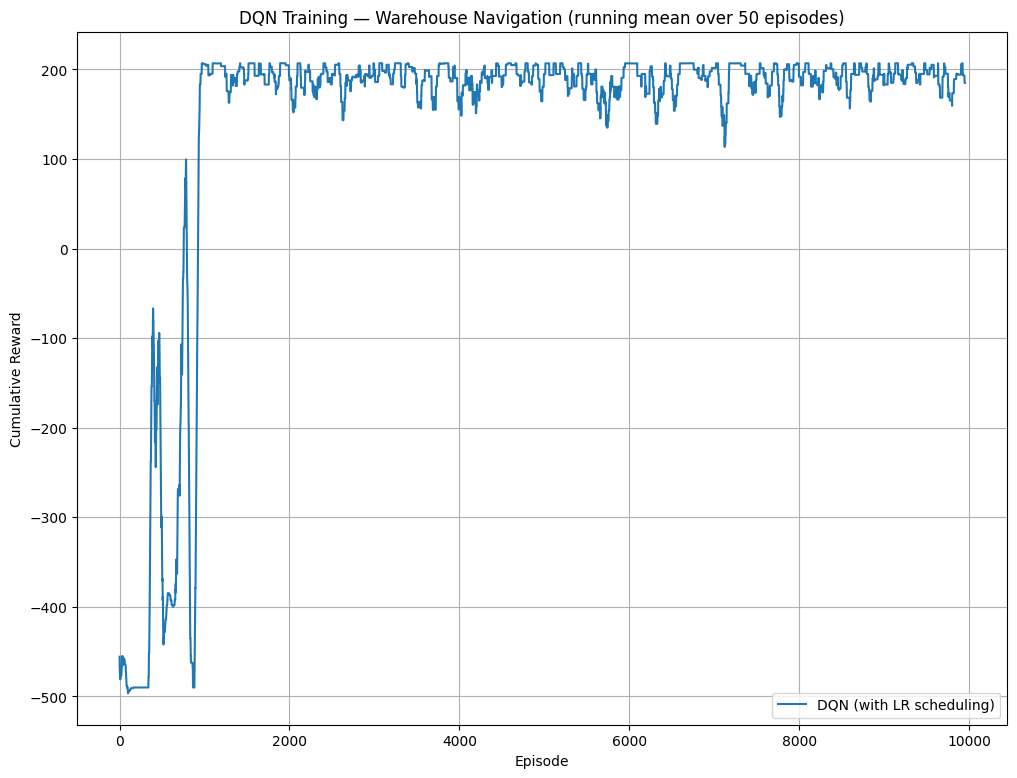

In [15]:
# plot results

# running mean function for the purpose of visualization
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0))
    return (cumsum[N:] - cumsum[:-N]) / float(N)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(running_mean(cumulative_rewards, 50), label="DQN (with LR scheduling)")
ax1.set_title("DQN Training — Warehouse Navigation (running mean over 50 episodes)")
ax1.set_ylabel("Cumulative Reward")
ax1.grid()
ax1.legend()

ax2.plot(running_mean(delivered_per_episode, 50), color='orange', label="Deliveries per Episode")
ax2.set_title("Deliveries per Episode (running mean over 50 episodes)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Packages Delivered")
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.savefig("warehouse_rewards_delivered_2.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
import pandas as pd

df = pd.DataFrame(cumulative_rewards, columns=['reward'])
df.to_csv('DQN.csv')